In [1]:
!pip install viennarna

In [2]:
!pip install forgi

In [3]:
import numpy as np
np.__version__

'1.26.4'

In [4]:
import RNA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
sequence = "AUGGCUACGUAGCUAGCUAGCUAGCUAUGCUAGCUAG"

In [ ]:
#structure prediction
structure,mfe=RNA.fold(sequence)
print("sequence:",sequence)
print("structure",structure)
print("m free energy",mfe)

sequence: AUGGCUACGUAGCUAGCUAGCUAGCUAUGCUAGCUAG
structure .(((((((((((((((....))))))))).)))))).
m free energy -19.200000762939453


In [7]:
#visulation base pairing
import forgi.visual.mplotlib as fvm
import forgi.graph.bulge_graph as fgb
import forgi

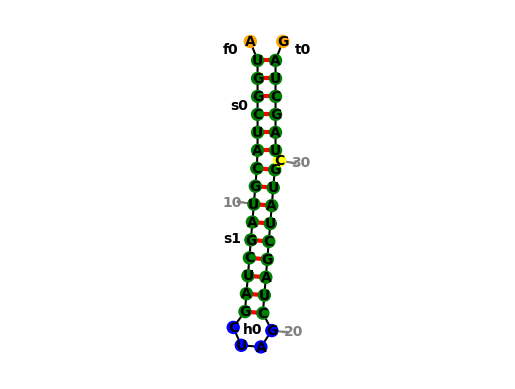

In [8]:
bg=fgb.BulgeGraph.from_dotbracket(structure,sequence)
fif,ax=plt.subplots()
fvm.plot_rna(bg,ax=ax)
plt.show()

In [9]:
#where is dot accesible
def accseible_region(structure):
  region=[]
  
  for i,s in enumerate(structure):
    if s=='.':
      region.append(i)
  return region
    

In [10]:
accseible_region(structure)

[0, 16, 17, 18, 19, 29, 36]

In [11]:
def accessible_score(structure, window=21):
    scores = []
    # Loop over starting positions where a full window fits
    for i in range(len(structure) - window + 1):
        fragment = structure[i:i+window] 
        score =fragment.count(".")/window
        scores.append(score)
    return scores

In [12]:
len(sequence)

37

In [15]:
scores=accessible_score(structure)
scores

[0.23809523809523808,
 0.19047619047619047,
 0.19047619047619047,
 0.19047619047619047,
 0.19047619047619047,
 0.19047619047619047,
 0.19047619047619047,
 0.19047619047619047,
 0.19047619047619047,
 0.23809523809523808,
 0.23809523809523808,
 0.23809523809523808,
 0.23809523809523808,
 0.23809523809523808,
 0.23809523809523808,
 0.23809523809523808,
 0.2857142857142857]

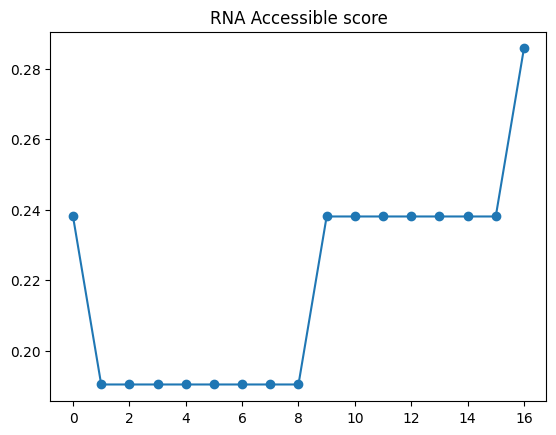

In [19]:
plt.plot(scores,marker='o')
plt.title("RNA Accessible score")
plt.show()

# RNA Secondary Structure Feature Enginerring pipeline

In [25]:
#sample data
data = {
    'siRNA': ['GCGAAACGC', 'AUGCUUAGC'],
    'mRNA_seq': ['GCGAAACGCUUAGC', 'AUGCUUAGCGGAAC'],
    'position': [0, 2],
    'efficacy': [0.8, 0.6]
}
df=pd.DataFrame(data)
df

,siRNA,mRNA_seq,position,efficacy
0,GCGAAACGC,GCGAAACGCUUAGC,0,0.8
1,AUGCUUAGC,AUGCUUAGCGGAAC,2,0.6


# feature eng

In [26]:
import RNA  # if not already imported

structures = []
mfes=[]
for seq in df["siRNA"]:                # iterate directly over sequences
    struc, mfe = RNA.fold(seq)         # fold the sequence
    structures.append(struc)
    mfes.append(mfe)

df["structure"] = structures   
df["mfe"]=mfes

In [27]:
df

,siRNA,mRNA_seq,position,efficacy,structure,mfe
0,GCGAAACGC,GCGAAACGCUUAGC,0,0.8,(((...))),-0.4
1,AUGCUUAGC,AUGCUUAGCGGAAC,2,0.6,.........,0.0


In [ ]:
paired_rate=[]
unpaired_rate=[]
